# Disciplina: Aprendizagem de Máquina
# Período: 2025.2 e 2026.1
# Professor: César Lincoln Cavalcante Mattos
# Aluno: Pedro Henrique Câmara Matos (devpedrocamara@gmail.com)

# Lista 2 - Regressão logística, métodos estatísticos, KNN e Árvores de decisão

### Instruções

#####• Algoritmos e modelos de implementações já existentes (e.g. scikit-learn) podem ser usados.

#####• Use de prints, gráficos e tabelas para apresentar o ajuste dos modelos e os resultados obtidos;

#####• Para a avaliação do trabalho, recomenda-se o envio de arquivo Jupyter notebook com os códigos executados e os resultados visíveis nas células.

##### Carregar Dataset

In [1]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

data_path_californiabin = '/content/drive/MyDrive/Classroom/[CTE-IA] Aprendizado de Máquina Prof. César Lincoln Mattos/Lista 2/ama_lista_02/californiabin.csv'

Mounted at /content/drive


In [2]:
ds_californiabin = pd.read_csv(data_path_californiabin)
ds_californiabin.head()

,4.168499999999999872e+00,2.000000000000000000e+01,6.700636942675159524e+00,1.178343949044585948e+00,7.450000000000000000e+02,2.372611464968152895e+00,3.879999999999999716e+01,-1.211500000000000057e+02,1.000000000000000000e+00
0,2.8194,24.0,4.762500,1.020833,608.0,2.533333,36.75,-119.85,0.0
1,2.4250,46.0,4.927711,1.018072,772.0,2.325301,36.33,-119.31,0.0
2,3.1205,16.0,3.728477,1.101545,1260.0,2.781457,33.87,-117.99,0.0
3,4.3889,41.0,5.741007,1.199041,837.0,2.007194,34.15,-118.40,1.0
4,2.9934,52.0,3.441379,1.020690,318.0,2.193103,37.57,-122.32,1.0


## Questão 1

###### Considere o conjunto de dados disponível em californiabin.csv, organizado em 9 colunas, sendo as 8 primeiras colunas os atributos e a última coluna a saída. Os 8 atributos são usados na predição de preços de casas em distritos da Califórnia na década de 1990. A saída é binária: 0, para abaixo da mediana dos preços; 1, para acima da mediana dos preços. Maiores detalhes sobre os dados podem ser conferidos em https://scikit-learn.org/stable/datasets/real_world.html#california-housing-dataset.

###### a) Considerando uma validação cruzada aninhada (nested K-fold) com 10 folds externos (estimação da generalização) e 5 folds internos (ajuste de hiperparâmetros), avalie modelos de classificação binária nos dados em questão.

######Para tanto, use as abordagens abaixo:
######– Regressão logística;
######– Análise do discriminante Gaussiano;
######– Naive Bayes Gaussiano;
######– KNN;
######– Árvore de decisão.

In [3]:
#  CÓDIGO ABAIXO

#### Separação das features (X) e target (y) a partir do dataframe 'ds_californiabin'

##### As primeiras oito colunas são dos atributos/'features'(X - variáveis independentes) e a última coluna é do alvo/target(Y - variável dependente), que queremos calcular.

In [4]:
# Atributos/Features (X) e Alvo (y)
X = ds_californiabin.iloc[:, :8]
y = ds_californiabin.iloc[:, 8]

print("Início dos Atributos (X):")
print(X.head())
print("\nInício do Alvo (y):")
print(y.head())

Início dos Atributos (X):
   4.168499999999999872e+00  2.000000000000000000e+01  \
0                    2.8194                      24.0   
1                    2.4250                      46.0   
2                    3.1205                      16.0   
3                    4.3889                      41.0   
4                    2.9934                      52.0   

   6.700636942675159524e+00  1.178343949044585948e+00  \
0                  4.762500                  1.020833   
1                  4.927711                  1.018072   
2                  3.728477                  1.101545   
3                  5.741007                  1.199041   
4                  3.441379                  1.020690   

   7.450000000000000000e+02  2.372611464968152895e+00  \
0                     608.0                  2.533333   
1                     772.0                  2.325301   
2                    1260.0                  2.781457   
3                     837.0                  2.007194   
4  

##### Inicializar cada modelo de classificação (Regressão Logística, Análise Discriminante Gaussiana, Naive Bayes Gaussiano, KNN, Árvore de Decisão) e definir um dicionário de hiperparâmetros com seus respectivos espaços de busca para a otimização de hiperparâmetros com o GridSearchCV.



In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# Regressão Logística
param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs']
}

# Análise de Discriminante Linear (LDA) - Sem hiperparâmetros para ajustar neste contexto
param_grid_lda = {}

# Análise de Discriminante Quadrático (QDA) - Sem hiperparâmetros para ajustar neste contexto
param_grid_qda = {}

# Naive Bayes Gaussiano - Sem hiperparâmetros para ajustar neste contexto
param_grid_gnb = {}

# K-Nearest Neighbors (KNN)
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance']
}

# Árvore de Decisão
param_grid_dt = {
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10]
}

# Cria uma lista de tuplas com os estimadores dos modelos e suas respectivas grades de hiperparâmetros
models_and_grids = [
    ('Regressão Logística', LogisticRegression(random_state=42, max_iter=200), param_grid_lr),
    ('LDA', LinearDiscriminantAnalysis(), param_grid_lda),
    ('QDA', QuadraticDiscriminantAnalysis(), param_grid_qda),
    ('Gaussian Naive Bayes', GaussianNB(), param_grid_gnb),
    ('KNN', KNeighborsClassifier(), param_grid_knn),
    ('Árvore de Decisão', DecisionTreeClassifier(random_state=42), param_grid_dt)
]

print("Modelos e grades de hiperparâmetros definidos")

Modelos e grades de hiperparâmetros definidos


#### Implementação Nested K-fold

##### Configuração do esquema de validação cruzada aninhada (Nested K-fold). Isso inclui 10 folds externos para a estimativa de generalização e 5 folds internos para o ajuste de hiperparâmetros. Para cada modelo, foi criado um pipeline que incluiu um StandardScaler, exceto para Árvore de decisão, e um objeto GridSearchCV (utilizando os folds internos e a grade de hiperparâmetros). Posteriormente, avaliou-se o pipeline do GridSearchCV usando a estratégia de validação cruzada externa para obter estimativas de desempenho imparciais.

In [6]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, average_precision_score
import numpy as np

# Inicializa as estratégias de validação cruzada externa e interna
outer_cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Dicionário para armazenar os resultados
results = {}

# Define as métricas de avaliação para o GridSearchCV
scoring_metrics = {
    'accuracy': 'accuracy',
    'recall': 'recall',
    'precision': 'precision',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
    'average_precision': 'average_precision' # Adicionado para PR-AUC
}

# Itera por cada modelo e sua respectiva grade de hiperparâmetros
for name, estimator, param_grid in models_and_grids:
    print(f"\nProcessando modelo: {name}")
    results[name] = {
        'accuracy': [],
        'recall': [],
        'precision': [],
        'f1': [],
        'roc_auc': [],
        'average_precision': [], # Adicionado para PR-AUC
        'y_test_folds': [],
        'y_pred_folds': [],
        'y_pred_proba_folds': []
    }

    # Prepara o objeto GridSearchCV com a validação cruzada interna (inner CV)
    # Se a param_grid estiver vazia, o GridSearchCV treinará o estimador sem ajuste de hiperparâmetros.
    grid_search = GridSearchCV(
        estimator=estimator,
        param_grid=param_grid,
        cv=inner_cv,
        scoring=scoring_metrics,
        refit='accuracy', # Reajusta o melhor modelo com base na acurácia
        n_jobs=-1,        # Usa todos os núcleos de processamento disponíveis
        verbose=0
    )

    # Itera sobre os folds externos (outer folds)
    for fold_idx, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # Cria um pipeline com StandardScaler e GridSearchCV
        # Lógica para desabilitar a padronização apenas para Árvore de Decisão
        scaler = StandardScaler() if name != 'Árvore de Decisão' else None

        pipeline = Pipeline([
            ('scaler', scaler),
            ('grid_search', grid_search)
        ])

        # Treina o pipeline nos dados de treino externos
        pipeline.fit(X_train, y_train)

        # Obtém o melhor estimador do GridSearchCV dentro do pipeline
        best_estimator = pipeline.named_steps['grid_search'].best_estimator_

        # Realiza predições de classe e de probabilidade no conjunto de teste externo
        y_pred = pipeline.predict(X_test)
        y_pred_proba = pipeline.predict_proba(X_test)[:, 1] # Probabilidade da classe positiva

        # Calcula e armazena as métricas
        results[name]['accuracy'].append(accuracy_score(y_test, y_pred))
        results[name]['recall'].append(recall_score(y_test, y_pred))
        results[name]['precision'].append(precision_score(y_test, y_pred))
        results[name]['f1'].append(f1_score(y_test, y_pred))
        results[name]['roc_auc'].append(roc_auc_score(y_test, y_pred_proba))
        results[name]['average_precision'].append(average_precision_score(y_test, y_pred_proba)) # Adicionado para PR-AUC

        # Armazena os valores reais e preditos para cada fold
        results[name]['y_test_folds'].append(y_test.tolist())
        results[name]['y_pred_folds'].append(y_pred.tolist())
        results[name]['y_pred_proba_folds'].append(y_pred_proba.tolist())

        print(f"  Fold {fold_idx + 1}/{outer_cv.n_splits} concluído para {name}", end='\r')

    print(f"\nProcessamento concluído para {name}")

print("Validação cruzada aninhada finalizada para todos os modelos.")


Processando modelo: Regressão Logística
  Fold 10/10 concluído para Regressão Logística
Processamento concluído para Regressão Logística

Processando modelo: LDA
  Fold 10/10 concluído para LDA
Processamento concluído para LDA

Processando modelo: QDA
  Fold 10/10 concluído para QDA
Processamento concluído para QDA

Processando modelo: Gaussian Naive Bayes
  Fold 10/10 concluído para Gaussian Naive Bayes
Processamento concluído para Gaussian Naive Bayes

Processando modelo: KNN
  Fold 10/10 concluído para KNN
Processamento concluído para KNN

Processando modelo: Árvore de Decisão
  Fold 10/10 concluído para Árvore de Decisão
Processamento concluído para Árvore de Decisão
Validação cruzada aninhada finalizada para todos os modelos.


###### b) Para cada modelo criado, considerando os valores obtidos nos folds externos, reporte valor médio e desvio padrão das métricas acurácia, revocação, precisão, F1-score e AUC-ROC.

In [7]:
#  CÓDIGO ABAIXO

In [8]:
# Dicionário de tradução para padronizar os nomes na saída do console
traducao_console = {
    'F1': 'F1-score',
    'Roc-auc': 'ROC-AUC',
    'Average-precision': 'PR-AUC'
}

print("\nResumo de Desempenho dos Modelos (Média +/- Desvio Padrão)")

for nome, metricas in results.items():
    print(f"\nModelo: {nome}")

    for nome_metrica, scores in metricas.items():
        if not nome_metrica.endswith('_folds'):  # Exclui os dados brutos dos folds

            # Calcula média e desvio padrão
            media = np.mean(scores)
            desvio = np.std(scores)

            # Formata o nome da métrica (Ex: roc_auc -> Roc-auc)
            nome_exibicao = nome_metrica.replace('_', '-').capitalize()

            # Aplica a tradução para os nomes específicos (F1-score, ROC-AUC, PR-AUC)
            nome_exibicao = traducao_console.get(nome_exibicao, nome_exibicao)

            print(f"  {nome_exibicao}: {media:.4f} +/- {desvio:.4f}")


Resumo de Desempenho dos Modelos (Média +/- Desvio Padrão)

Modelo: Regressão Logística
  Accuracy: 0.8424 +/- 0.0234
  Recall: 0.8468 +/- 0.0364
  Precision: 0.8402 +/- 0.0284
  F1-score: 0.8429 +/- 0.0241
  ROC-AUC: 0.9172 +/- 0.0167
  PR-AUC: 0.9190 +/- 0.0196

Modelo: LDA
  Accuracy: 0.8399 +/- 0.0307
  Recall: 0.8629 +/- 0.0371
  Precision: 0.8255 +/- 0.0331
  F1-score: 0.8434 +/- 0.0301
  ROC-AUC: 0.9143 +/- 0.0182
  PR-AUC: 0.9125 +/- 0.0224

Modelo: QDA
  Accuracy: 0.8159 +/- 0.0317
  Recall: 0.8839 +/- 0.0344
  Precision: 0.7795 +/- 0.0367
  F1-score: 0.8278 +/- 0.0275
  ROC-AUC: 0.9024 +/- 0.0262
  PR-AUC: 0.9067 +/- 0.0296

Modelo: Gaussian Naive Bayes
  Accuracy: 0.7574 +/- 0.0328
  Recall: 0.7217 +/- 0.0886
  Precision: 0.7872 +/- 0.0627
  F1-score: 0.7471 +/- 0.0358
  ROC-AUC: 0.8528 +/- 0.0287
  PR-AUC: 0.8529 +/- 0.0350

Modelo: KNN
  Accuracy: 0.8434 +/- 0.0259
  Recall: 0.8589 +/- 0.0430
  Precision: 0.8331 +/- 0.0223
  F1-score: 0.8453 +/- 0.0280
  ROC-AUC: 0.9210 +

##### Tabela de resultados do Nested K-fold

In [9]:
# Preparação dos dados para a tabela
resumo_formatado = []

# Dicionário de tradução para as colunas da tabela
traducao_colunas = {
    'F1': 'F1-score',
    'Roc_auc': 'ROC-AUC',
    'Average_precision': 'PR-AUC'
}

for nome, metricas in results.items():
    linha = {'Modelo': nome}
    for nome_metrica, scores in metricas.items():
        if not nome_metrica.endswith('_folds'):
            nome_exibicao = nome_metrica.capitalize()
            nome_exibicao = traducao_colunas.get(nome_exibicao, nome_exibicao)

            media_val = np.mean(scores)
            desvio_val = np.std(scores)

            # Formata a string com média e desvio padrão
            linha[nome_exibicao] = f"{media_val:.3f} ± {desvio_val:.3f}"
            # Guarda o valor numérico bruto para o cálculo de destaque (negrito)
            linha[f'{nome_exibicao}_bruto'] = media_val

    resumo_formatado.append(linha)

# 2. Criar DataFrame e organizar as colunas
df_bruto = pd.DataFrame(resumo_formatado)
colunas_para_exibir = ['Modelo'] + [c for c in df_bruto.columns if not c.endswith('_bruto') and c != 'Modelo']
df_limpo = df_bruto[colunas_para_exibir]

# 3. Função para aplicar negrito nos valores máximos (ajustada para df sem índice)
def destacar_maximo(s):
    if s.name == 'Modelo':
        return ['' for _ in s]

    coluna_bruta = f"{s.name}_bruto"
    if coluna_bruta in df_bruto.columns:
        # Identifica o valor máximo na coluna de dados numéricos brutos
        e_maximo = df_bruto[coluna_bruta] == df_bruto[coluna_bruta].max()
        return ['font-weight: bold; color: red' if v else '' for v in e_maximo]
    return ['' for _ in s]

# 4. Estilização final da tabela para exibição no Jupyter
tabela_estilizada = df_limpo.style.apply(destacar_maximo, axis=0)\
    .hide(axis='index')\
    .set_table_styles([
        {'selector': 'th', 'props': [('text-align', 'center'), ('padding', '10px')]},
        {'selector': 'td', 'props': [('text-align', 'center'), ('padding', '10px')]}
    ])

print("Tabela de Desempenho: Média ± Desvio Padrão")
display(tabela_estilizada)

Tabela de Desempenho: Média ± Desvio Padrão


Modelo,Accuracy,Recall,Precision,F1-score,ROC-AUC,PR-AUC
Regressão Logística,0.842 ± 0.023,0.847 ± 0.036,0.840 ± 0.028,0.843 ± 0.024,0.917 ± 0.017,0.919 ± 0.020
LDA,0.840 ± 0.031,0.863 ± 0.037,0.826 ± 0.033,0.843 ± 0.030,0.914 ± 0.018,0.913 ± 0.022
QDA,0.816 ± 0.032,0.884 ± 0.034,0.780 ± 0.037,0.828 ± 0.028,0.902 ± 0.026,0.907 ± 0.030
Gaussian Naive Bayes,0.757 ± 0.033,0.722 ± 0.089,0.787 ± 0.063,0.747 ± 0.036,0.853 ± 0.029,0.853 ± 0.035
KNN,0.843 ± 0.026,0.859 ± 0.043,0.833 ± 0.022,0.845 ± 0.028,0.921 ± 0.022,0.918 ± 0.023
Árvore de Decisão,0.809 ± 0.028,0.798 ± 0.042,0.817 ± 0.031,0.807 ± 0.030,0.837 ± 0.033,0.790 ± 0.043


#### Curvas ROC/PRC médias

Plotando curvas

 Modelo: Regressão Logística 


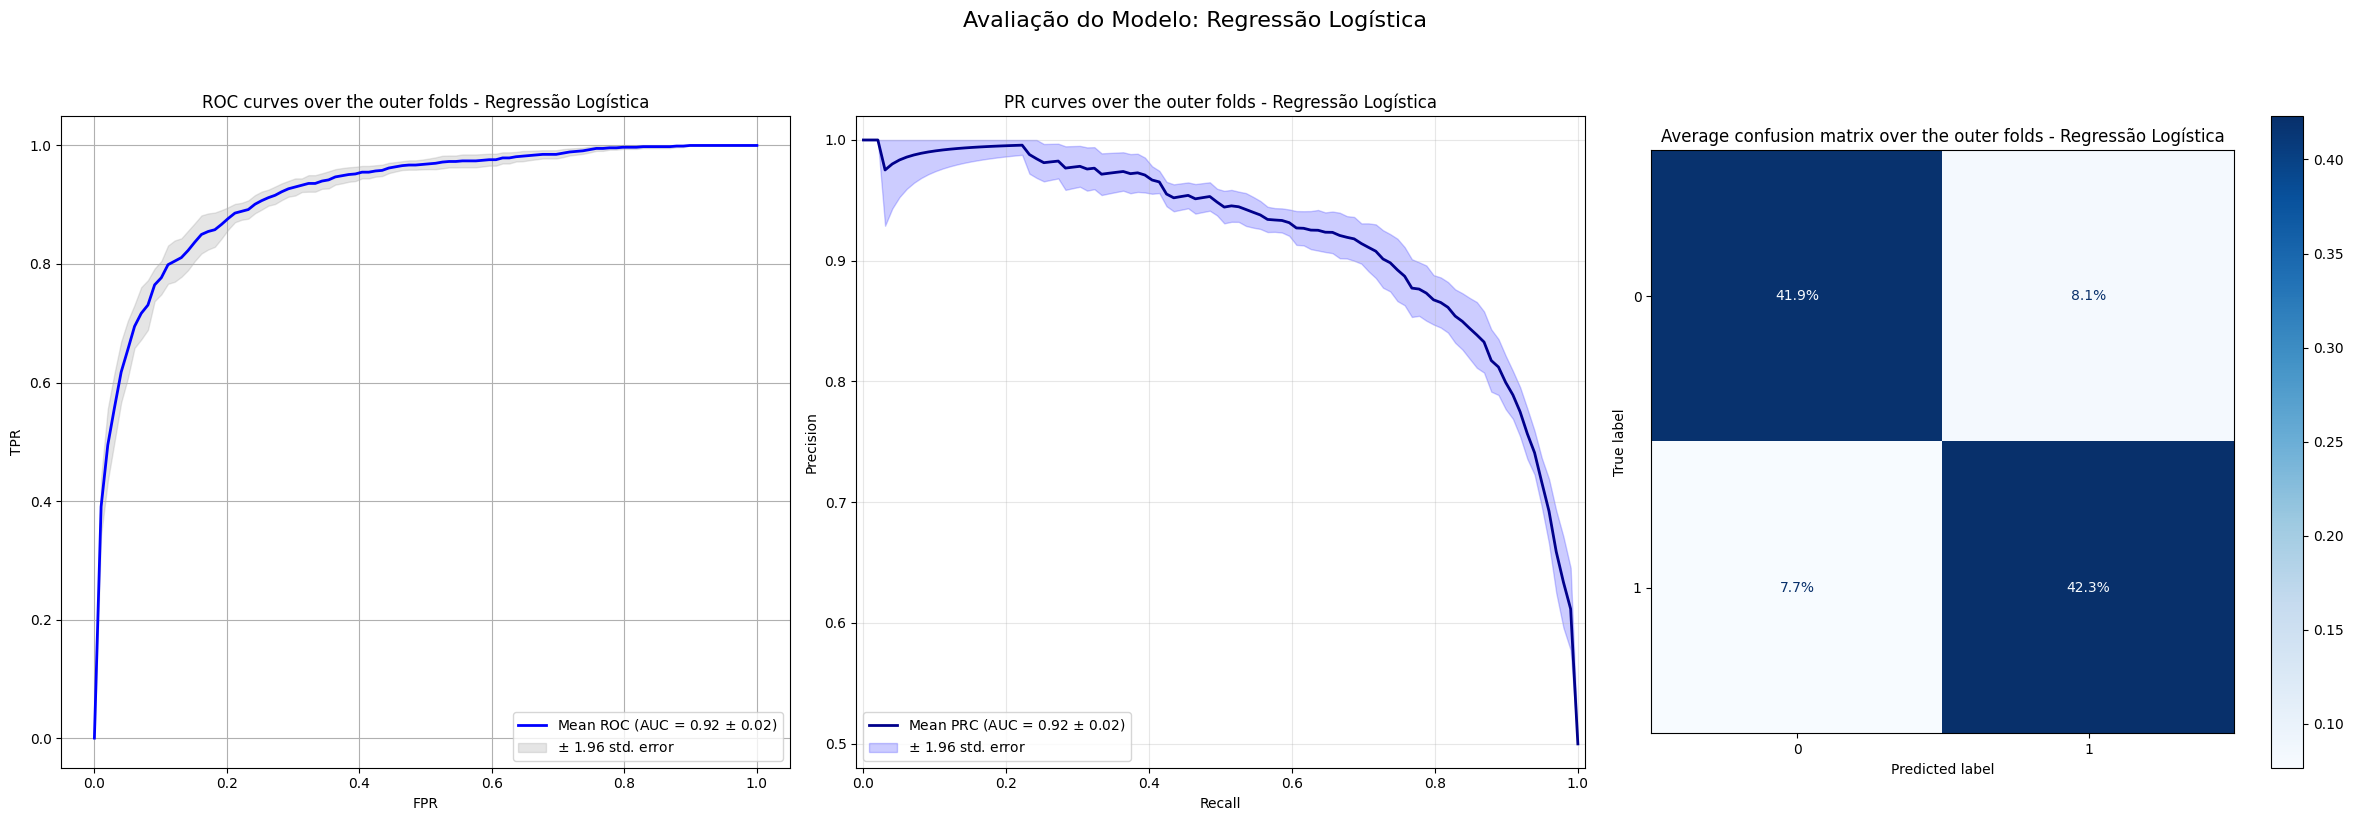


 Modelo: LDA 


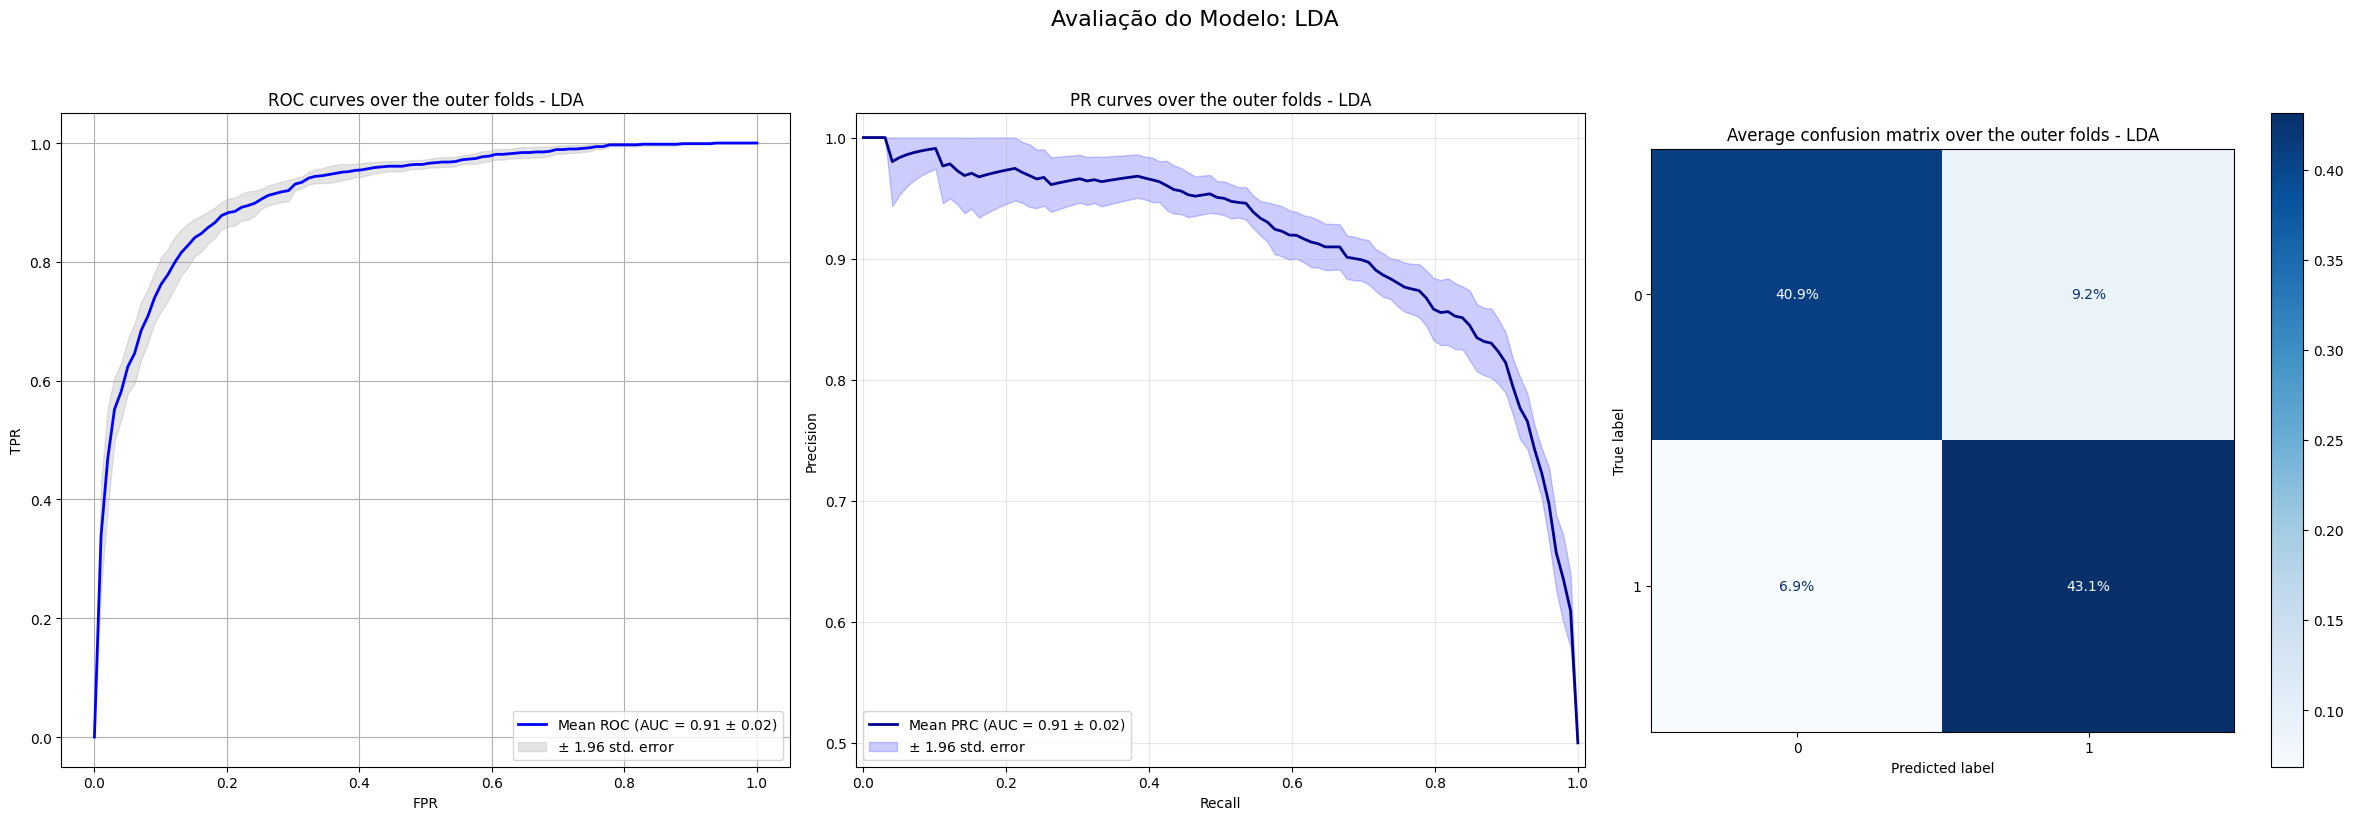


 Modelo: QDA 


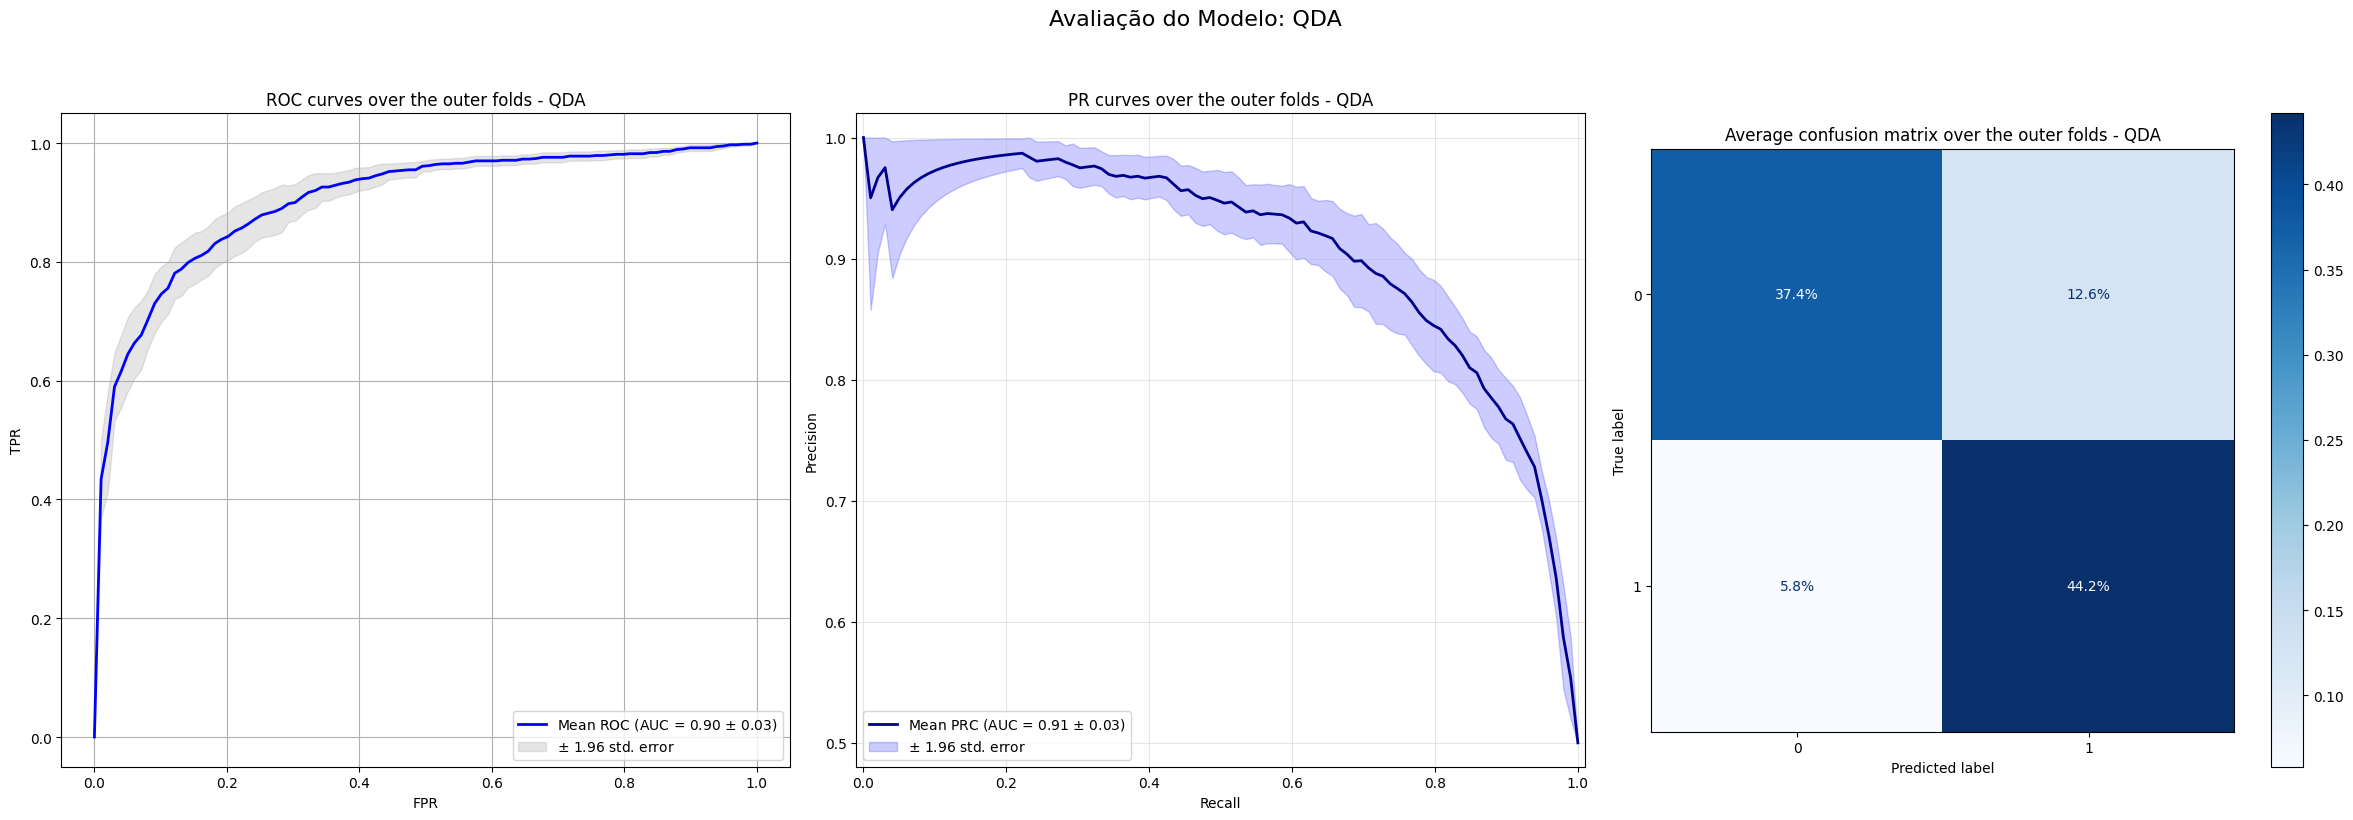


 Modelo: Gaussian Naive Bayes 


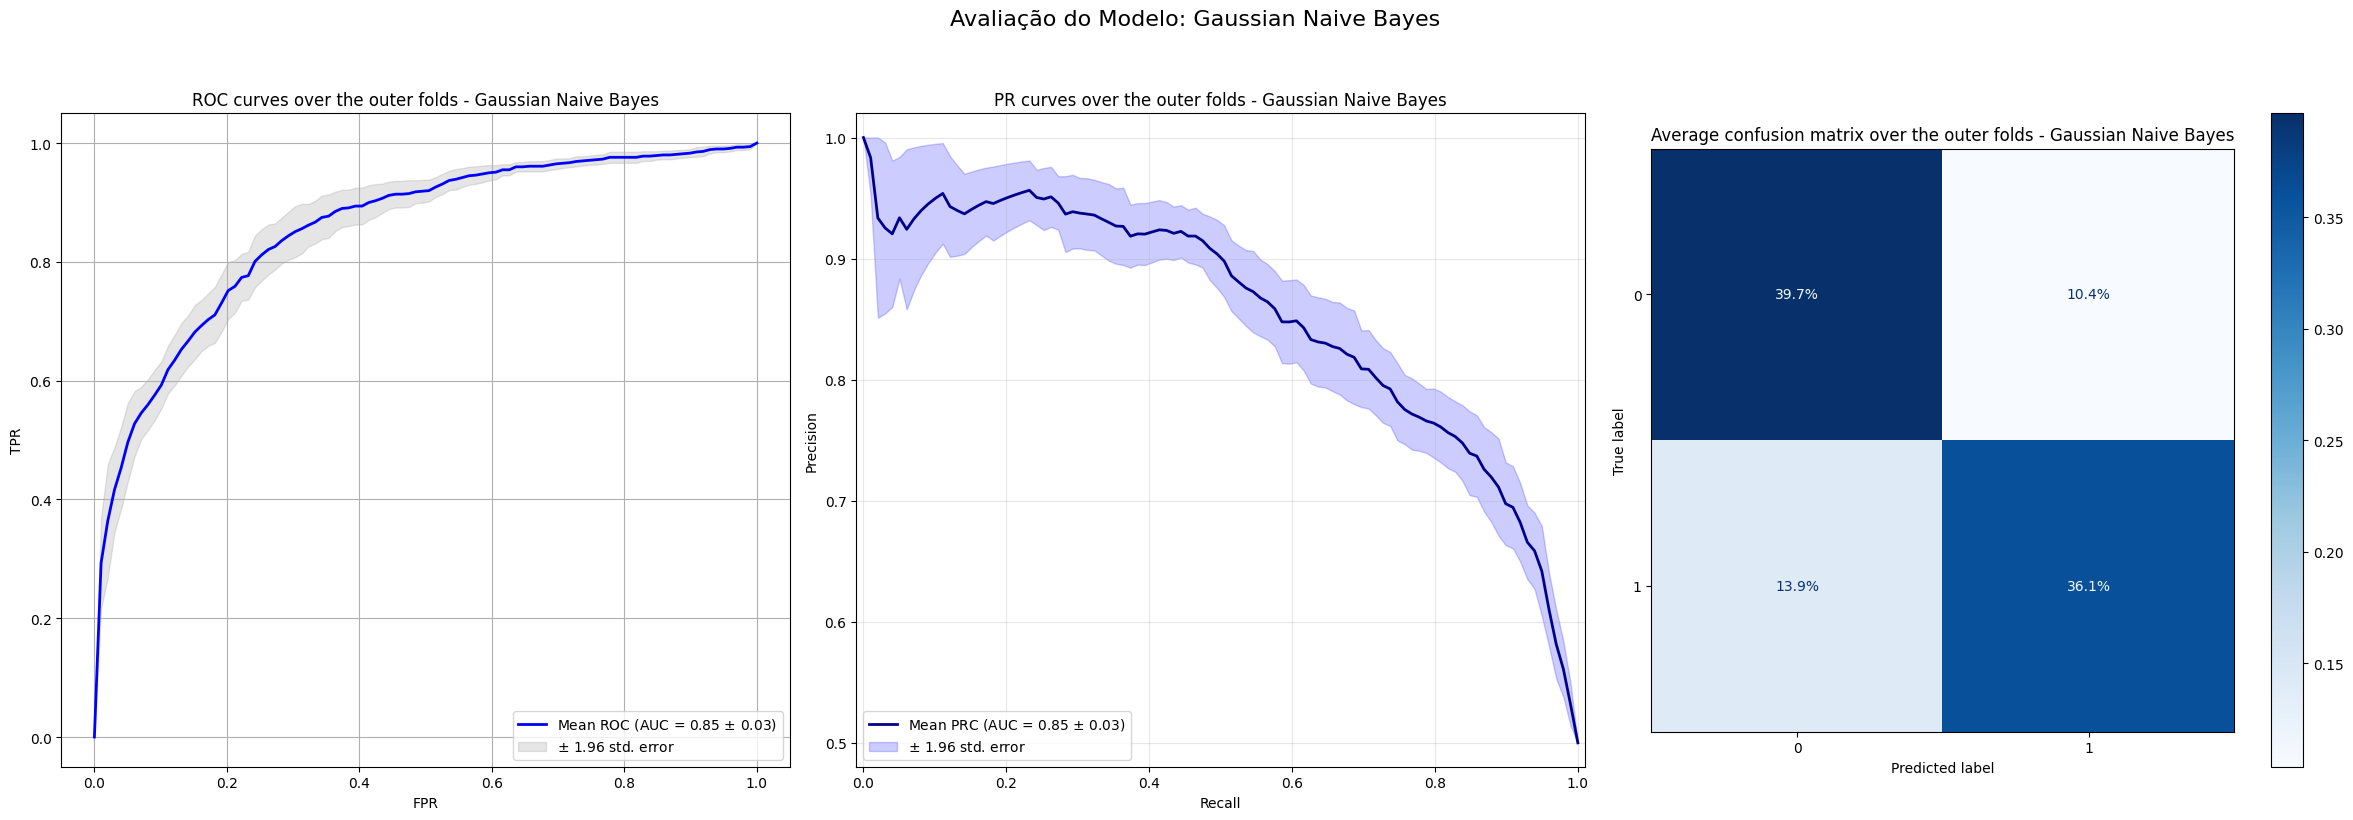


 Modelo: KNN 


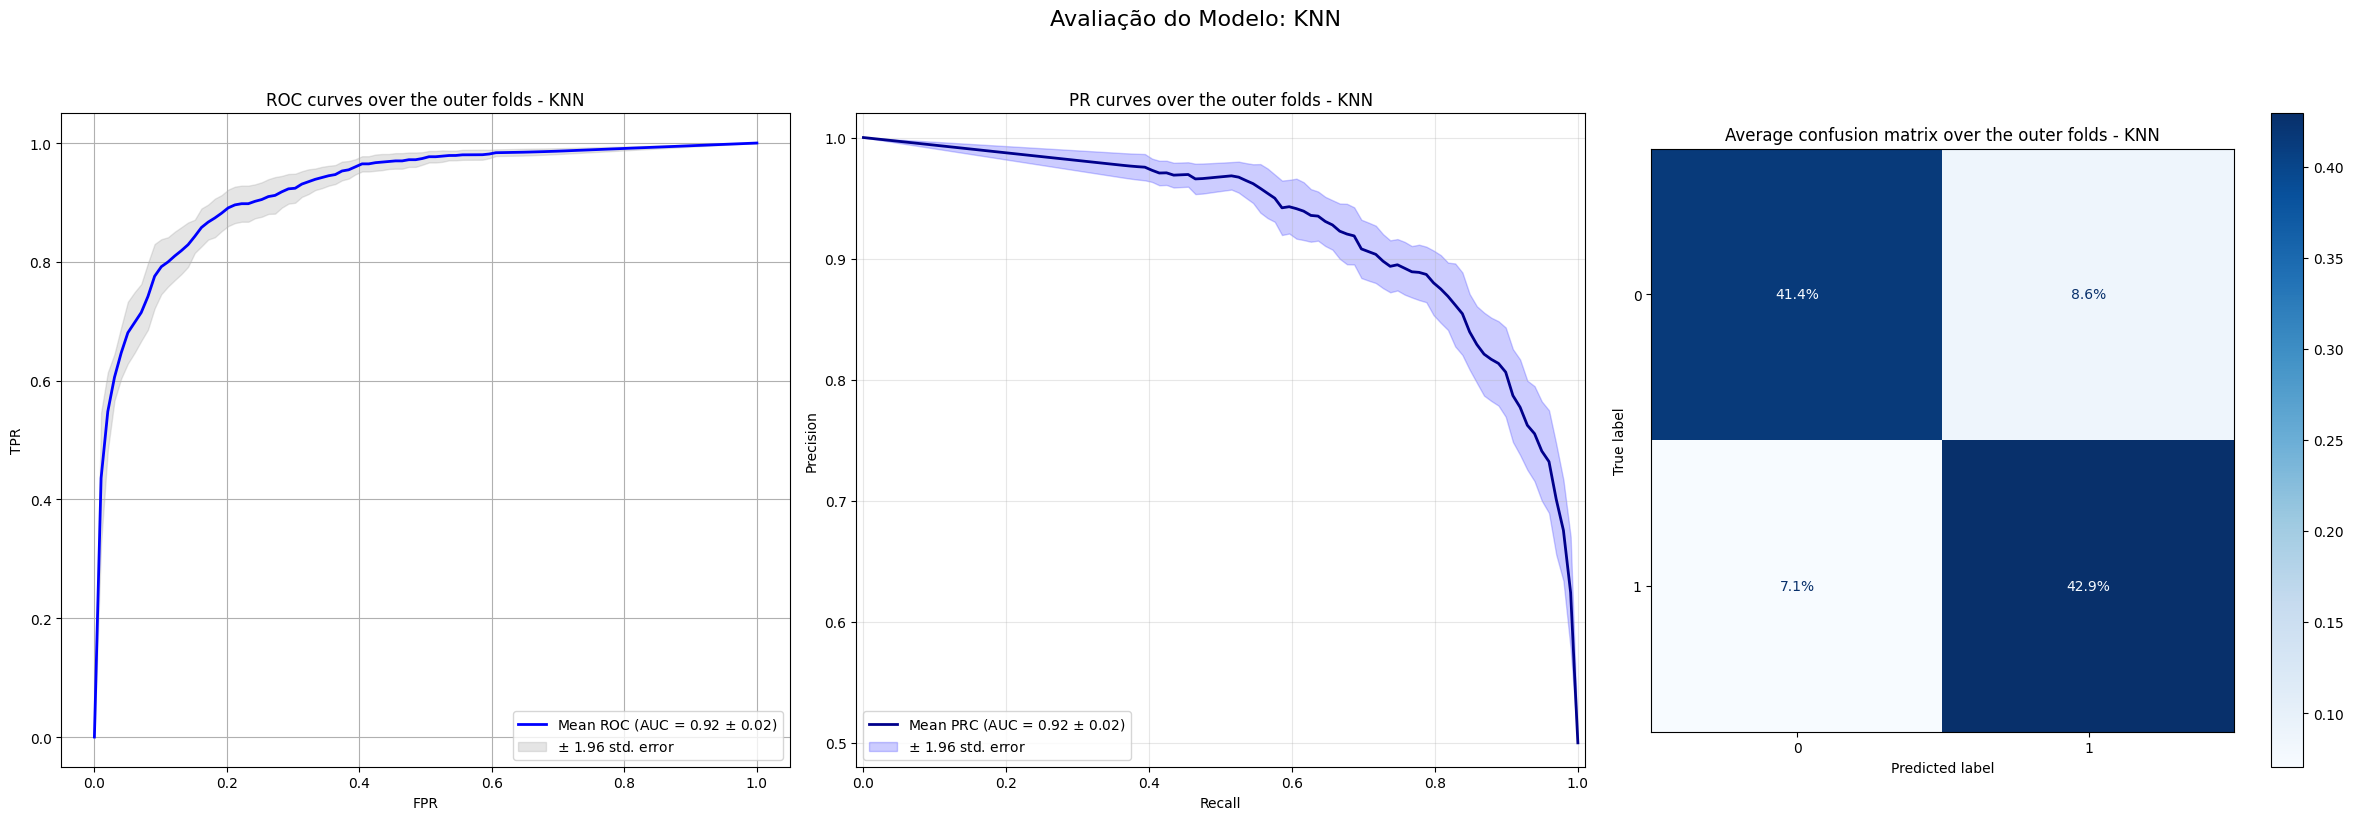


 Modelo: Árvore de Decisão 


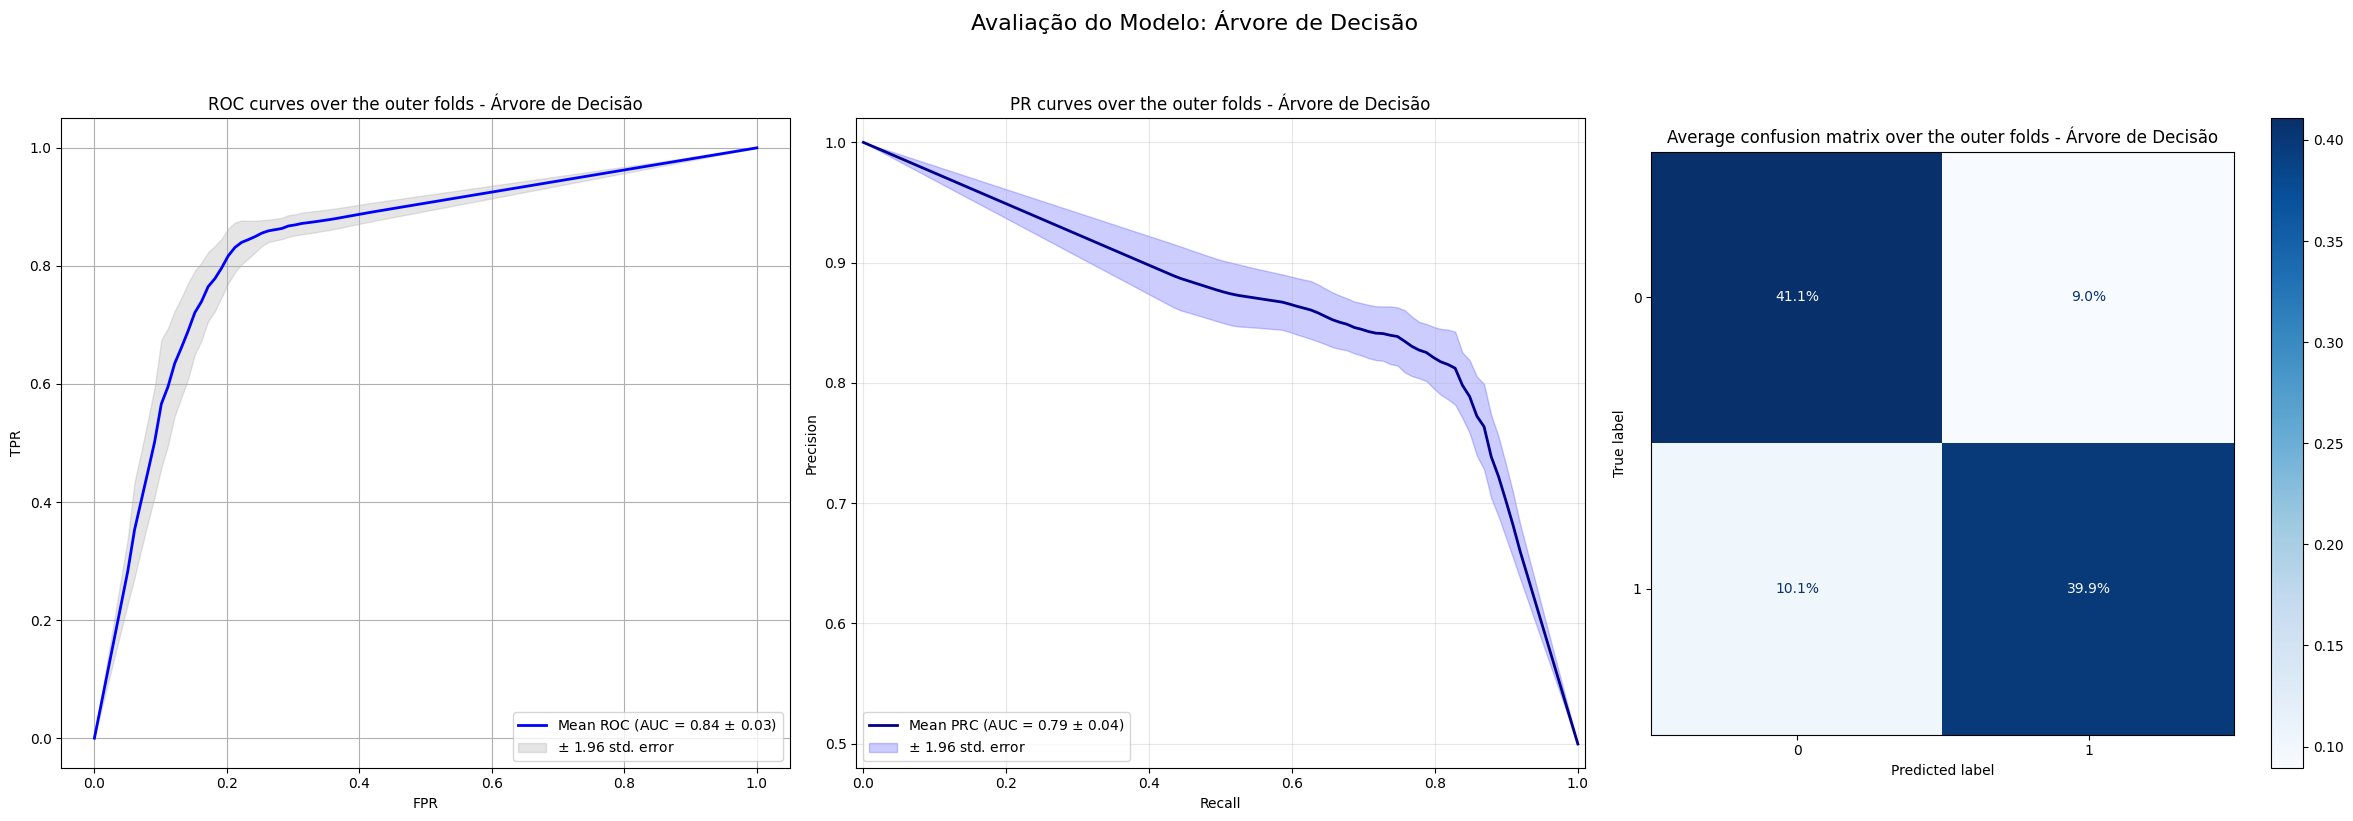

In [10]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, average_precision_score, precision_recall_curve, PrecisionRecallDisplay
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, RocCurveDisplay

print("Plotando curvas")

# Define intervalos comuns para interpolação das curvas
mean_fpr_ci = np.linspace(0, 1, 100)
mean_recall_axis = np.linspace(0, 1, 100)

for name, metrics in results.items():
    print(f"\n Modelo: {name} ")

    # Agregação de dados para os cálculos globais (todos os folds)
    all_y_test = [item for sublist in metrics['y_test_folds'] for item in sublist]
    all_y_pred = [item for sublist in metrics['y_pred_folds'] for item in sublist]
    all_y_pred_proba = [item for sublist in metrics['y_pred_proba_folds'] for item in sublist]

    # Configuração da Figura Principal com 3 Subplots
    fig, axes = plt.subplots(1, 3, figsize=(24, 8))

    # Subplot 1: Curva ROC com Intervalo de Confiança
    ax_roc_ci = axes[0]
    tprs = []
    aucs = []

    for fold_idx in range(outer_cv.n_splits):
        y_test_fold = metrics['y_test_folds'][fold_idx]
        y_pred_proba_fold = metrics['y_pred_proba_folds'][fold_idx]

        fpr_fold, tpr_fold, _ = roc_curve(y_test_fold, y_pred_proba_fold)
        interp_tpr = np.interp(mean_fpr_ci, fpr_fold, tpr_fold)
        interp_tpr[0] = 0.0
        tprs.append(interp_tpr)
        aucs.append(roc_auc_score(y_test_fold, y_pred_proba_fold))

    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0
    mean_auc = np.mean(aucs)
    std_auc = np.std(aucs)

    # Cálculo do Erro Padrão para o Intervalo de Confiança
    std_err_tpr = np.std(tprs, axis=0) / np.sqrt(outer_cv.n_splits)
    tprs_upper = np.minimum(mean_tpr + 1.96 * std_err_tpr, 1)
    tprs_lower = np.maximum(mean_tpr - 1.96 * std_err_tpr, 0)

    ax_roc_ci.plot(mean_fpr_ci, mean_tpr, color='b',
                   label=r'Mean ROC (AUC = %0.2f $\pm$ %0.2f)' % (mean_auc, std_auc), lw=2)
    ax_roc_ci.fill_between(mean_fpr_ci, tprs_lower, tprs_upper, color='grey', alpha=.2,
                           label=r'$\pm$ 1.96 std. error')

    ax_roc_ci.set_xlabel('FPR')
    ax_roc_ci.set_ylabel('TPR')
    ax_roc_ci.set_title(f'ROC curves over the outer folds - {name}')
    ax_roc_ci.legend(loc="lower right")
    ax_roc_ci.grid(True)

    # Subplot 2 - Curva Precision-Recall com Intervalo de Confiança
    ax_pr_ci = axes[1]
    precisions = []
    pr_aucs = []

    for fold_idx in range(outer_cv.n_splits):
        y_test_fold = metrics['y_test_folds'][fold_idx]
        y_pred_proba_fold = metrics['y_pred_proba_folds'][fold_idx]

        prec_fold, rec_fold, _ = precision_recall_curve(y_test_fold, y_pred_proba_fold)
        # Invertemos para a interpolação funcionar corretamente (Recall crescente)
        interp_prec = np.interp(mean_recall_axis, rec_fold[::-1], prec_fold[::-1])
        precisions.append(interp_prec)
        pr_aucs.append(average_precision_score(y_test_fold, y_pred_proba_fold))

    mean_precision = np.mean(precisions, axis=0)
    mean_pr_auc = np.mean(pr_aucs)
    std_pr_auc = np.std(pr_aucs)

    std_err_prec = np.std(precisions, axis=0) / np.sqrt(outer_cv.n_splits)
    prec_upper = np.minimum(mean_precision + 1.96 * std_err_prec, 1)
    prec_lower = np.maximum(mean_precision - 1.96 * std_err_prec, 0)

    ax_pr_ci.plot(mean_recall_axis, mean_precision, color='darkblue',
                  label=r'Mean PRC (AUC = %0.2f $\pm$ %0.2f)' % (mean_pr_auc, std_pr_auc), lw=2)
    ax_pr_ci.fill_between(mean_recall_axis, prec_lower, prec_upper, color='blue', alpha=.2,
                          label=r'$\pm$ 1.96 std. error')

    ax_pr_ci.set_xlim([-0.01, 1.01])
    ax_pr_ci.set_ylim([0.48, 1.02])
    ax_pr_ci.set_xlabel('Recall')
    ax_pr_ci.set_ylabel('Precision')
    ax_pr_ci.set_title(f'PR curves over the outer folds - {name}')
    ax_pr_ci.legend(loc="lower left")
    ax_pr_ci.grid(True, linestyle='-', alpha=0.3)

    # Subplot 3: Matriz de Confusão (Porcentagem do Total)
    ax_cm = axes[2]
    cm_absolute = confusion_matrix(all_y_test, all_y_pred)
    cm_percentage = cm_absolute.astype('float') / cm_absolute.sum()

    disp_cm = ConfusionMatrixDisplay(confusion_matrix=cm_percentage, display_labels=[0, 1])
    disp_cm.plot(cmap=plt.cm.Blues, ax=ax_cm, values_format='.1%')

    ax_cm.set_title(f'Average confusion matrix over the outer folds - {name}')
    ax_cm.grid(False)

    #  Ajustes Finais da Figura(Cabeçalho)
    fig.suptitle(f'Avaliação do Modelo: {name}', fontsize=16, y=1.02)
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()

    plt.close(fig)

####Conclusão:

#####Com base nesses resultados, o KNN e a Regressão Logística parecem ser os modelos de melhor desempenho em termos de acurácia e ROC-AUC. O KNN apresenta a maior acurácia média (0,8434) e ROC-AUC (0,9210), seguido de perto pela Regressão Logística.